# MIS 433 Final Project: AI Investment Signals

For this project, we are looking at a few major AI-related companies and seeing if stock trends, volume, volatility, and news sentiment can help give a short-term investment signal.

The companies we are using are NVDA, MSFT, GOOGL, AMZN, AMD, and AVGO. Instead of trying to predict the exact stock price, we are focusing on whether the stock might move up or down over the next 7 trading days.


## 1. Environment Setup

This section sets up the notebook. It works in Colab, but it can also run locally in VS Code from the project folder.


In [1]:
import os
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    possible_project_dirs = [
        Path('/content/MIS433-Final-Project'),
        Path('/content/drive/MyDrive/MIS_433_Project'),
        Path.cwd()
    ]

    PROJECT_DIR = None
    for folder in possible_project_dirs:
        if (folder / 'README.md').exists() or (folder / 'notebooks').exists():
            PROJECT_DIR = folder
            break

    if PROJECT_DIR is None:
        PROJECT_DIR = Path('/content/drive/MyDrive/MIS_433_Project')
        PROJECT_DIR.mkdir(parents=True, exist_ok=True)

    os.chdir(PROJECT_DIR)
    print(f"Running in Google Colab: {PROJECT_DIR}")
else:
    current_dir = Path.cwd().resolve()
    PROJECT_DIR = current_dir.parent if current_dir.name == 'notebooks' else current_dir
    os.chdir(PROJECT_DIR)
    print(f"Running locally in VS Code: {PROJECT_DIR}")

Path('data/raw').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('data/external').mkdir(parents=True, exist_ok=True)
Path('outputs/charts').mkdir(parents=True, exist_ok=True)
Path('outputs/model_results').mkdir(parents=True, exist_ok=True)
Path('outputs/screenshots').mkdir(parents=True, exist_ok=True)


Running locally in VS Code: C:\Users\Carlos\Documents\MIS_433_Project


In [2]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn requests google-generativeai



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")


## 2. Stock Data Collection

Here we use `yfinance` to pull the historical stock data from Yahoo Finance for each company.


In [4]:
tickers = ["NVDA", "MSFT", "GOOGL", "AMZN", "AMD", "AVGO"]
start_date = "2020-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")


In [5]:
stock_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    group_by="ticker"
)

stock_data.head()


[                       0%                       ]

[****************      33%                       ]  2 of 6 completed

[**********************50%                       ]  3 of 6 completed

[**********************50%                       ]  3 of 6 completed

[**********************83%***************        ]  5 of 6 completed

[*********************100%***********************]  6 of 6 completed

Ticker            AMD                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2020-01-02  46.860001  49.250000  46.630001  49.099998  49.099998  80331100   
2020-01-03  48.029999  49.389999  47.540001  48.599998  48.599998  73127400   
2020-01-06  48.020000  48.860001  47.860001  48.389999  48.389999  47934900   
2020-01-07  49.349998  49.389999  48.040001  48.250000  48.250000  58061400   
2020-01-08  47.849998  48.299999  47.139999  47.830002  47.830002  53767000   

Ticker           AVGO                                   ...     NVDA           \
Price            Open       High        Low      Close  ...      Low    Close   
Date                                                    ...                     
2020-01-02  31.931999  32.250000  31.732000  32.238998  ...  5.91800  5.99775   
2020-01-03  31.750999  32.000000  31.408001  31.419001  ...  5.85250  5.90175   
2020-01-06  31.084999  31.392000  30.962999  31.372000  ...  5.78175  5.92650   
2020-01-07  31.525000  31.658001  31.225000  31.264000  ...  5.90975  5.99825   
2020-01-08  31.298000  31.349001  30.841000  30.874001  ...  5.95375  6.00950   

Ticker                                 MSFT                          \
Price      Adj Close     Volume        Open        High         Low   
Date                                                                  
2020-01-02  5.970754  237536000  158.779999  160.729996  158.330002   
2020-01-03  5.875187  205384000  158.320007  159.949997  158.059998   
2020-01-06  5.899825  262636000  157.080002  159.100006  156.509995   
2020-01-07  5.971252  314856000  159.320007  159.669998  157.320007   
2020-01-08  5.982450  277108000  158.929993  160.800003  157.949997   

Ticker                                        
Price            Close   Adj Close    Volume  
Date                                          
2020-01-02  160.619995  151.829559  22622100  
2020-01-03  158.619995  149.939011  21116200  
2020-01-06  159.029999  150.326538  20813700  
2020-01-07  157.580002  148.955963  21634100  
2020-01-08  160.089996  151.328537  27746500  

[5 rows x 36 columns]

In [6]:
stock_data.to_csv("data/raw/stock_prices_raw.csv")


## 3. Data Cleaning

The stock data comes in a wide format, so this section cleans it up into one table that is easier to use.


In [7]:
clean_data = []

for ticker in tickers:
    temp = stock_data[ticker].copy()
    temp["ticker"] = ticker
    temp = temp.reset_index()
    clean_data.append(temp)

stock_df = pd.concat(clean_data, ignore_index=True)
stock_df.columns = [col.lower().replace(" ", "_") for col in stock_df.columns]
stock_df["date"] = pd.to_datetime(stock_df["date"])

stock_df.head()


,date,open,high,low,close,adj_close,volume,ticker
0,2020-01-02,5.96875,5.99775,5.91800,5.99775,5.970754,237536000,NVDA
1,2020-01-03,5.87750,5.94575,5.85250,5.90175,5.875187,205384000,NVDA
2,2020-01-06,5.80800,5.93175,5.78175,5.92650,5.899825,262636000,NVDA
3,2020-01-07,5.95500,6.04425,5.90975,5.99825,5.971252,314856000,NVDA
4,2020-01-08,5.99400,6.05100,5.95375,6.00950,5.982450,277108000,NVDA


In [8]:
stock_df.to_csv("data/processed/stock_prices_clean.csv", index=False)


## 4. Exploratory Data Analysis

This section looks at the data with a few basic charts and summary stats so we can compare the companies.


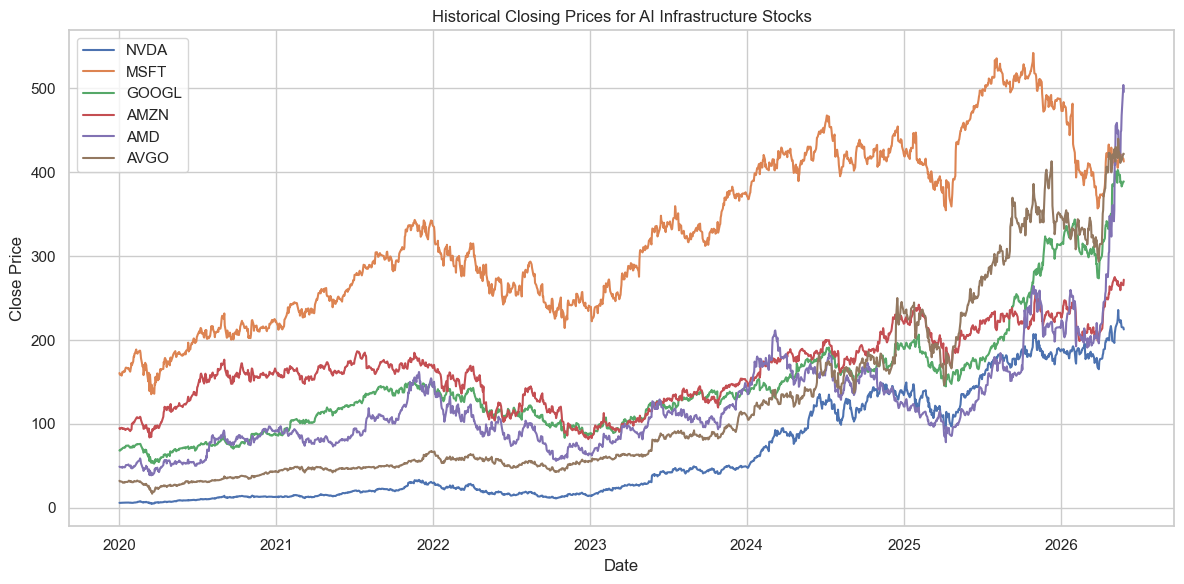

In [9]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    temp = stock_df[stock_df["ticker"] == ticker]
    plt.plot(temp["date"], temp["close"], label=ticker)

plt.title("Historical Closing Prices for AI Infrastructure Stocks")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
stock_df.info()
stock_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       9648 non-null   datetime64[ns]
 1   open       9648 non-null   float64       
 2   high       9648 non-null   float64       
 3   low        9648 non-null   float64       
 4   close      9648 non-null   float64       
 5   adj_close  9648 non-null   float64       
 6   volume     9648 non-null   int64         
 7   ticker     9648 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 603.1+ KB


,date,open,high,low,close,adj_close,volume
count,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000,9.648000e+03
mean,2023-03-13 12:04:28.656716544,157.891352,159.944675,155.743905,157.917795,156.045555,1.007328e+08
min,2020-01-02 00:00:00,5.002500,5.248500,4.517000,4.910000,4.890824,4.123000e+06
25%,2021-08-05 18:00:00,79.247499,80.493250,77.714499,78.864248,78.545002,2.507865e+07
50%,2023-03-13 12:00:00,136.511749,138.329750,134.612503,136.380005,135.533936,3.951690e+07
75%,2024-10-16 06:00:00,206.862503,209.669994,203.277496,206.357506,203.093964,7.693980e+07
max,2026-05-27 00:00:00,555.229980,555.450012,540.770020,542.070007,538.658508,1.543911e+09
std,NaN,112.109990,113.158298,110.945047,112.115799,110.925724,1.561691e+08


## 5. Feature Engineering

Here we add new columns that can help with the model, like returns, moving averages, volatility, and volume change.


In [11]:
stock_df = stock_df.sort_values(["ticker", "date"])

stock_df["daily_return"] = stock_df.groupby("ticker")["close"].pct_change()
stock_df["return_3d"] = stock_df.groupby("ticker")["close"].pct_change(3)
stock_df["return_5d"] = stock_df.groupby("ticker")["close"].pct_change(5)
stock_df["return_7d"] = stock_df.groupby("ticker")["close"].pct_change(7)
stock_df["return_10d"] = stock_df.groupby("ticker")["close"].pct_change(10)
stock_df["return_14d"] = stock_df.groupby("ticker")["close"].pct_change(14)
stock_df["return_30d"] = stock_df.groupby("ticker")["close"].pct_change(30)

stock_df["ma_7d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=7).mean())
stock_df["ma_14d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=14).mean())
stock_df["ma_30d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=30).mean())
stock_df["ma_90d"] = stock_df.groupby("ticker")["close"].transform(lambda x: x.rolling(window=90).mean())

stock_df["volatility_7d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=7).std())
stock_df["volatility_14d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=14).std())
stock_df["volatility_30d"] = stock_df.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(window=30).std())

stock_df["volume_change"] = stock_df.groupby("ticker")["volume"].pct_change()
stock_df["avg_volume_30d"] = stock_df.groupby("ticker")["volume"].transform(lambda x: x.rolling(window=30).mean())
stock_df["volume_vs_avg_30d"] = stock_df["volume"] / stock_df["avg_volume_30d"]

stock_df["close_vs_ma_30d"] = (stock_df["close"] / stock_df["ma_30d"]) - 1
stock_df["ma_7d_vs_30d"] = (stock_df["ma_7d"] / stock_df["ma_30d"]) - 1

stock_df.head()


,date,open,high,low,close,adj_close,volume,ticker,daily_return,return_3d,...,ma_30d,ma_90d,volatility_7d,volatility_14d,volatility_30d,volume_change,avg_volume_30d,volume_vs_avg_30d,close_vs_ma_30d,ma_7d_vs_30d
6432,2020-01-02,46.860001,49.250000,46.630001,49.099998,49.099998,80331100,AMD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6433,2020-01-03,48.029999,49.389999,47.540001,48.599998,48.599998,73127400,AMD,-0.010183,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.089675,NaN,NaN,NaN,NaN
6434,2020-01-06,48.020000,48.860001,47.860001,48.389999,48.389999,47934900,AMD,-0.004321,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.344502,NaN,NaN,NaN,NaN
6435,2020-01-07,49.349998,49.389999,48.040001,48.250000,48.250000,58061400,AMD,-0.002893,-0.017312,...,NaN,NaN,NaN,NaN,NaN,0.211255,NaN,NaN,NaN,NaN
6436,2020-01-08,47.849998,48.299999,47.139999,47.830002,47.830002,53767000,AMD,-0.008705,-0.015844,...,NaN,NaN,NaN,NaN,NaN,-0.073963,NaN,NaN,NaN,NaN


In [12]:
stock_df.to_csv("data/processed/stock_features.csv", index=False)


## 6. Stock Performance Comparisons

This section compares the stocks visually. The normalized chart helps because the companies all have different stock prices.


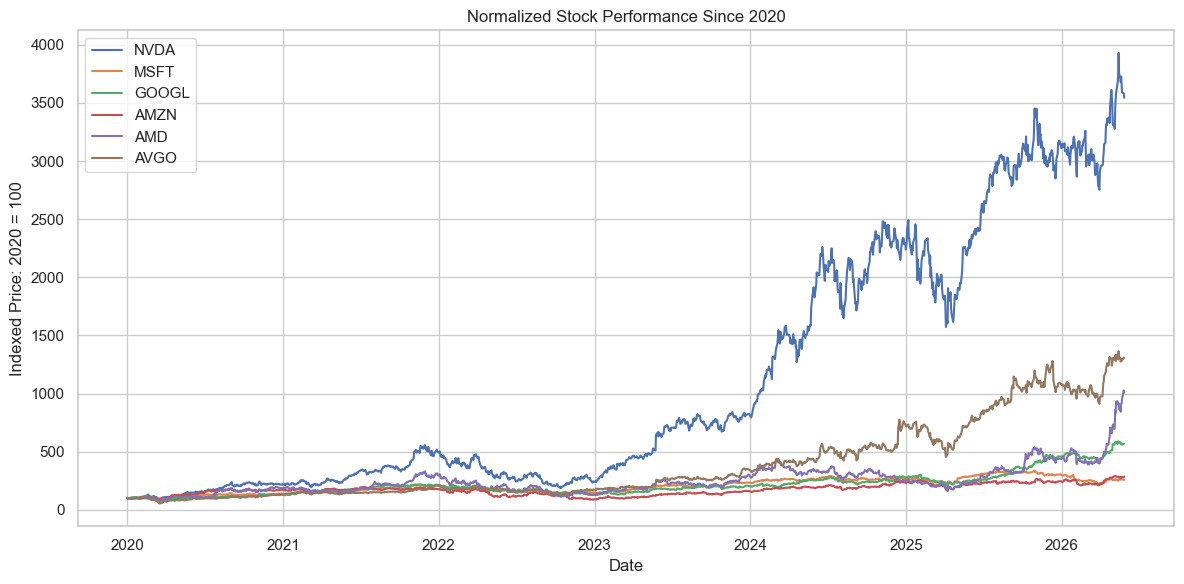

In [13]:
normalized_df = stock_df.copy()
normalized_df["normalized_close"] = normalized_df.groupby("ticker")["close"].transform(lambda x: x / x.iloc[0] * 100)

plt.figure(figsize=(12, 6))

for ticker in tickers:
    temp = normalized_df[normalized_df["ticker"] == ticker]
    plt.plot(temp["date"], temp["normalized_close"], label=ticker)

plt.title("Normalized Stock Performance Since 2020")
plt.xlabel("Date")
plt.ylabel("Indexed Price: 2020 = 100")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/normalized_stock_performance.png", dpi=300, bbox_inches="tight")
plt.show()


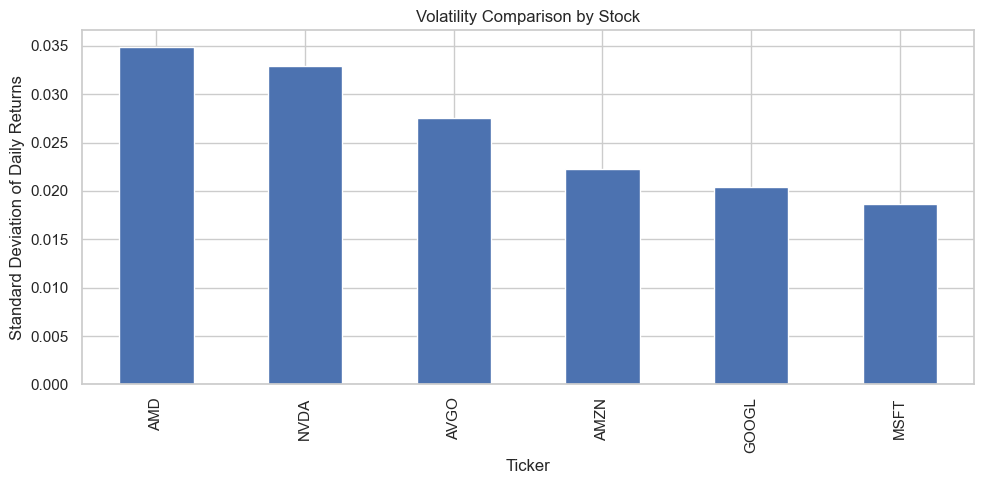

In [14]:
volatility_summary = stock_df.groupby("ticker")["daily_return"].std().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
volatility_summary.plot(kind="bar")
plt.title("Volatility Comparison by Stock")
plt.xlabel("Ticker")
plt.ylabel("Standard Deviation of Daily Returns")
plt.tight_layout()
plt.savefig("outputs/charts/volatility_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
summary = stock_df.groupby("ticker").agg(
    start_price=("close", "first"),
    end_price=("close", "last"),
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std"),
    avg_volume=("volume", "mean")
).reset_index()

summary["total_return"] = (summary["end_price"] / summary["start_price"]) - 1
summary = summary.sort_values("total_return", ascending=False)

summary


,ticker,start_price,end_price,avg_daily_return,volatility,avg_volume,total_return
5,NVDA,5.997750,212.600006,0.002761,0.032945,3.944737e+08,34.446628
2,AVGO,32.238998,421.859985,0.001979,0.027552,2.508011e+07,12.085394
0,AMD,49.099998,495.540009,0.002040,0.034857,5.982180e+07,9.092465
3,GOOGL,68.433998,388.829987,0.001289,0.020377,3.347907e+07,4.681825
1,AMZN,94.900497,271.850006,0.000903,0.022291,6.349906e+07,1.864579
4,MSFT,160.619995,412.670013,0.000762,0.018691,2.804282e+07,1.569232


## 7. News Sentiment Data from Alpha Vantage

This section pulls recent news sentiment from Alpha Vantage. The sentiment score is positive for more positive news, negative for more negative news, and close to zero for neutral news.

The API key can come from Colab Secrets or from a local `.env` file. This keeps the key out of the notebook and out of GitHub.


In [16]:
import os
import requests
import time

try:
    from google.colab import userdata
    alpha_key = userdata.get("ALPHA_VANTAGE_API_KEY")
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()
    alpha_key = os.getenv("ALPHA_VANTAGE_API_KEY")

if not alpha_key or alpha_key == "your_alpha_vantage_api_key_here":
    raise ValueError("Alpha Vantage API key not found. Add it to Colab Secrets or your local .env file.")

all_sentiment = []

for ticker in tickers:
    print(f"Pulling sentiment for {ticker}...")

    params = {
        "function": "NEWS_SENTIMENT",
        "tickers": ticker,
        "apikey": alpha_key,
        "limit": 50
    }

    response = requests.get("https://www.alphavantage.co/query", params=params)
    data = response.json()

    if "feed" not in data:
        print(f"No feed returned for {ticker}: {data}")
        continue

    for article in data.get("feed", []):
        for ticker_info in article.get("ticker_sentiment", []):
            if ticker_info["ticker"] == ticker:
                all_sentiment.append({
                    "ticker": ticker,
                    "date": article["time_published"][:8],
                    "title": article["title"],
                    "source": article["source"],
                    "url": article["url"],
                    "ticker_sentiment_score": float(ticker_info["ticker_sentiment_score"]),
                    "ticker_sentiment_label": ticker_info["ticker_sentiment_label"],
                    "relevance_score": float(ticker_info["relevance_score"])
                })

    time.sleep(12)

sentiment_df = pd.DataFrame(all_sentiment)

if sentiment_df.empty:
    print("No new sentiment rows returned. The next cell will use saved daily sentiment if available.")

sentiment_df.head()


Pulling sentiment for NVDA...


No feed returned for NVDA: {'Information': 'We have detected your API key as OEBFMOCRDQCZ4EZT and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.'}
Pulling sentiment for MSFT...
No feed returned for MSFT: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
Pulling sentiment for GOOGL...


No feed returned for GOOGL: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
Pulling sentiment for AMZN...
No feed returned for AMZN: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
Pulling sentiment for AMD...


No feed returned for AMD: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
Pulling sentiment for AVGO...
No feed returned for AVGO: {'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}
No new sentiment rows returned. The next cell will use saved daily sentiment if available.


""


In [17]:
daily_sentiment_path = Path("data/external/daily_sentiment_scores.csv")
using_saved_daily_sentiment = False

if sentiment_df.empty:
    if daily_sentiment_path.exists():
        print("Using saved daily sentiment scores.")
        daily_sentiment = pd.read_csv(daily_sentiment_path)
        daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"], errors="coerce")
        using_saved_daily_sentiment = True
    else:
        print("No sentiment data available. Creating empty sentiment columns.")
        daily_sentiment = pd.DataFrame(columns=[
            "ticker", "date", "avg_sentiment_score", "avg_relevance_score", "article_count"
        ])
else:
    sentiment_df["date"] = pd.to_datetime(sentiment_df["date"], errors="coerce")

    if sentiment_df["date"].isna().all() and daily_sentiment_path.exists():
        print("Raw sentiment dates were not usable, so using saved daily sentiment scores.")
        daily_sentiment = pd.read_csv(daily_sentiment_path)
        daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"], errors="coerce")
        using_saved_daily_sentiment = True
    else:
        daily_sentiment = sentiment_df.groupby(["ticker", "date"]).agg(
            avg_sentiment_score=("ticker_sentiment_score", "mean"),
            avg_relevance_score=("relevance_score", "mean"),
            article_count=("title", "count")
        ).reset_index()

daily_sentiment


Using saved daily sentiment scores.


,ticker,date,avg_sentiment_score,avg_relevance_score,article_count
0,AMD,2026-05-27,0.155694,0.638067,19
1,AMD,2026-05-28,0.193455,0.665473,31
2,AMZN,2026-05-27,0.127651,0.736662,13
3,AMZN,2026-05-28,0.183193,0.731671,36
4,AMZN,2026-05-29,0.433087,1.000000,1
5,AVGO,2026-05-26,0.132127,0.634095,6
6,AVGO,2026-05-27,0.294311,0.759963,24
7,AVGO,2026-05-28,0.190800,0.609882,20
8,GOOGL,2026-05-27,0.128446,0.715441,23
9,GOOGL,2026-05-28,0.161826,0.687589,27


In [18]:
if not sentiment_df.empty and not using_saved_daily_sentiment:
    sentiment_df.to_csv("data/external/alpha_vantage_news_sentiment_raw.csv", index=False)
else:
    print("Skipping raw sentiment save because saved daily sentiment was used.")

daily_sentiment.to_csv("data/external/daily_sentiment_scores.csv", index=False)

daily_sentiment["ticker"].value_counts()


Skipping raw sentiment save because saved daily sentiment was used.


ticker
AMZN     3
AVGO     3
AMD      2
GOOGL    2
MSFT     2
NVDA     1
Name: count, dtype: int64

## 8. Combining Stock and Sentiment Data

Here we add the latest sentiment score for each company to the stock dataset so it can be used as another feature.


In [19]:
latest_sentiment = daily_sentiment.sort_values("date").groupby("ticker").tail(1)

latest_sentiment = latest_sentiment[[
    "ticker",
    "avg_sentiment_score",
    "avg_relevance_score",
    "article_count"
]]

stock_df = pd.read_csv("data/processed/stock_features.csv")
stock_df["date"] = pd.to_datetime(stock_df["date"])

stock_df = stock_df.merge(latest_sentiment, on="ticker", how="left")

stock_df["avg_sentiment_score"] = stock_df["avg_sentiment_score"].fillna(0)
stock_df["avg_relevance_score"] = stock_df["avg_relevance_score"].fillna(0)
stock_df["article_count"] = stock_df["article_count"].fillna(0)

stock_df.head()


,date,open,high,low,close,adj_close,volume,ticker,daily_return,return_3d,...,volatility_14d,volatility_30d,volume_change,avg_volume_30d,volume_vs_avg_30d,close_vs_ma_30d,ma_7d_vs_30d,avg_sentiment_score,avg_relevance_score,article_count
0,2020-01-02,46.860001,49.250000,46.630001,49.099998,49.099998,80331100,AMD,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.193455,0.665473,31
1,2020-01-03,48.029999,49.389999,47.540001,48.599998,48.599998,73127400,AMD,-0.010183,NaN,...,NaN,NaN,-0.089675,NaN,NaN,NaN,NaN,0.193455,0.665473,31
2,2020-01-06,48.020000,48.860001,47.860001,48.389999,48.389999,47934900,AMD,-0.004321,NaN,...,NaN,NaN,-0.344502,NaN,NaN,NaN,NaN,0.193455,0.665473,31
3,2020-01-07,49.349998,49.389999,48.040001,48.250000,48.250000,58061400,AMD,-0.002893,-0.017312,...,NaN,NaN,0.211255,NaN,NaN,NaN,NaN,0.193455,0.665473,31
4,2020-01-08,47.849998,48.299999,47.139999,47.830002,47.830002,53767000,AMD,-0.008705,-0.015844,...,NaN,NaN,-0.073963,NaN,NaN,NaN,NaN,0.193455,0.665473,31


In [20]:
stock_df.to_csv("data/processed/stock_features_with_sentiment.csv", index=False)


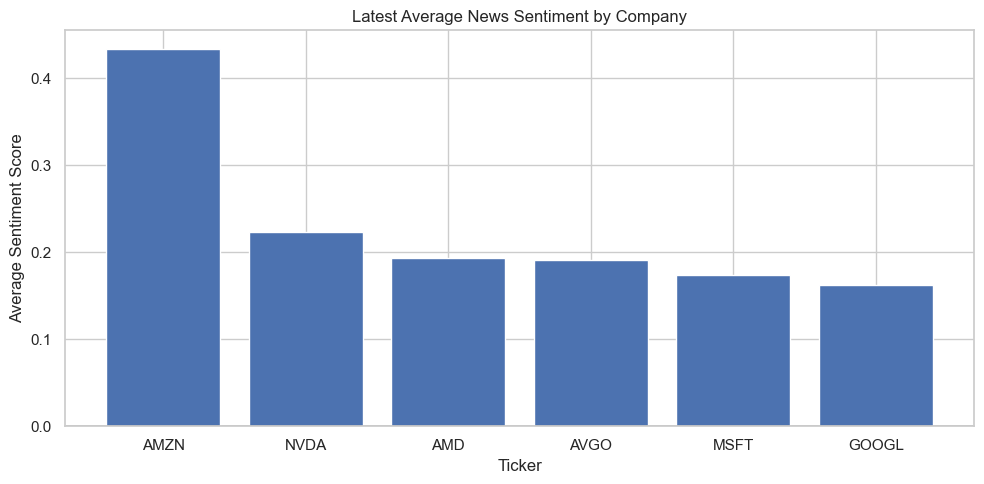

In [21]:
sentiment_summary = latest_sentiment.sort_values("avg_sentiment_score", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(sentiment_summary["ticker"], sentiment_summary["avg_sentiment_score"])
plt.title("Latest Average News Sentiment by Company")
plt.xlabel("Ticker")
plt.ylabel("Average Sentiment Score")
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig("outputs/charts/latest_sentiment_by_company.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Prediction Target

This section creates the target column for the model. A `1` means the stock went up 7 trading days later, and a `0` means it did not.


In [22]:
stock_df = pd.read_csv("data/processed/stock_features_with_sentiment.csv")
stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df = stock_df.sort_values(["ticker", "date"])

prediction_windows = [3, 5, 7, 10]

for window in prediction_windows:
    stock_df[f"future_close_{window}d"] = stock_df.groupby("ticker")["close"].shift(-window)
    stock_df[f"future_return_{window}d"] = (stock_df[f"future_close_{window}d"] / stock_df["close"]) - 1
    stock_df[f"target_up_{window}d"] = (stock_df[f"future_return_{window}d"] > 0).where(
        stock_df[f"future_close_{window}d"].notna()
    )
    stock_df[f"target_up_{window}d"] = stock_df[f"target_up_{window}d"].astype("Int64")

feature_columns = [
    "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
    "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
    "volatility_7d", "volatility_14d", "volatility_30d",
    "volume_change", "volume_vs_avg_30d", "avg_sentiment_score", "article_count"
]

training_df = stock_df.dropna(subset=feature_columns + ["target_up_7d"]).copy()
training_df["target_up_7d"] = training_df["target_up_7d"].astype(int)
latest_prediction_df = stock_df[stock_df["target_up_7d"].isna()].copy()

print(f"Model-ready rows: {len(stock_df)}")
print(f"Training rows with known 7-day target: {len(training_df)}")
print(f"Latest rows for future prediction only: {len(latest_prediction_df)}")

stock_df[[
    "date", "ticker", "close", "future_close_3d", "future_close_5d",
    "future_close_7d", "future_close_10d", "future_return_7d", "target_up_7d"
]].head(10)


Model-ready rows: 9648
Training rows with known 7-day target: 9072
Latest rows for future prediction only: 42


,date,ticker,close,future_close_3d,future_close_5d,future_close_7d,future_close_10d,future_return_7d,target_up_7d
0,2020-01-02,AMD,49.099998,48.250000,48.970001,48.750000,49.770000,-0.007128,0
1,2020-01-03,AMD,48.599998,47.830002,48.169998,48.209999,50.930000,-0.008025,0
2,2020-01-06,AMD,48.389999,48.970001,48.750000,48.549999,51.049999,0.003306,1
3,2020-01-07,AMD,48.250000,48.169998,48.209999,49.770000,51.430000,0.031503,1
4,2020-01-08,AMD,47.830002,48.750000,48.549999,50.930000,51.709999,0.064813,1
5,2020-01-09,AMD,48.970001,48.209999,49.770000,51.049999,50.349998,0.042475,1
6,2020-01-10,AMD,48.169998,48.549999,50.930000,51.430000,49.259998,0.067677,1
7,2020-01-13,AMD,48.750000,49.770000,51.049999,51.709999,50.529999,0.060718,1
8,2020-01-14,AMD,48.209999,50.930000,51.430000,50.349998,47.509998,0.044389,1
9,2020-01-15,AMD,48.549999,51.049999,51.709999,49.259998,48.779999,0.014624,1


In [23]:
stock_df.to_csv("data/processed/model_ready_stock_data.csv", index=False)
training_df.to_csv("data/processed/training_ready_stock_data.csv", index=False)
latest_prediction_df.to_csv("data/processed/latest_prediction_rows.csv", index=False)


## 10. Model Testing and Tuning

This section tests a few simple models and settings to see which one works best. The model uses the cleaned stock data and sentiment data already created in this notebook.

The target is still based on the next 7 trading days. Instead of predicting the exact future price, the model predicts whether the stock has a meaningful upward move.

To reduce noise, this section tests a few movement cutoffs like 0.5%, 1%, 1.5%, and 2%. This helps us see if the model works better when it focuses on clearer stock moves instead of tiny daily changes.


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = pd.read_csv("data/processed/model_ready_stock_data.csv")
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values(["date", "ticker"])

feature_groups = {
    "price_volume_only": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
        "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_7d", "volatility_14d", "volatility_30d",
        "volume_change", "volume_vs_avg_30d", "ticker"
    ],
    "price_volume_sentiment": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d", "return_14d", "return_30d",
        "ma_7d", "ma_14d", "ma_30d", "ma_90d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_7d", "volatility_14d", "volatility_30d",
        "volume_change", "volume_vs_avg_30d", "avg_sentiment_score", "article_count", "ticker"
    ],
    "short_term_signals": [
        "daily_return", "return_3d", "return_5d", "return_7d", "return_10d",
        "volatility_7d", "volatility_14d", "volume_change", "volume_vs_avg_30d",
        "avg_sentiment_score", "article_count", "ticker"
    ],
    "trend_signals": [
        "return_7d", "return_14d", "return_30d", "ma_7d_vs_30d", "close_vs_ma_30d",
        "volatility_30d", "volume_vs_avg_30d", "avg_sentiment_score", "ticker"
    ]
}

print(f"Rows available before modeling: {len(model_df)}")
print("Date range:", model_df["date"].min().date(), "to", model_df["date"].max().date())
print("Feature groups tested:")
for name, columns in feature_groups.items():
    print(f"- {name}: {len(columns)} features")


Rows available before modeling: 9648
Date range: 2020-01-02 to 2026-05-27
Feature groups tested:
- price_volume_only: 19 features
- price_volume_sentiment: 21 features
- short_term_signals: 12 features
- trend_signals: 9 features


In [25]:
def make_preprocessor(feature_columns, scale_numeric=False):
    numeric_columns = [col for col in feature_columns if col != "ticker"]
    numeric_step = StandardScaler() if scale_numeric else "passthrough"

    return ColumnTransformer([
        ("numeric", numeric_step, numeric_columns),
        ("ticker", OneHotEncoder(handle_unknown="ignore"), ["ticker"])
    ])

def predict_with_threshold(model, X, threshold=None):
    if threshold is None or not hasattr(model, "predict_proba"):
        return model.predict(X)

    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(int)

def evaluate_model_versions(data, feature_groups):
    rows = []
    trained_models = {}

    prediction_windows = [3, 5, 7, 10]
    movement_cutoffs = [0.005, 0.01, 0.015, 0.02, 0.025]
    probability_thresholds = [0.40, 0.43, 0.45, 0.47, 0.50]

    for window in prediction_windows:
        future_return_column = f"future_return_{window}d"

        for cutoff in movement_cutoffs:
            cutoff_df = data.dropna(subset=[future_return_column]).copy()
            cutoff_df = cutoff_df[cutoff_df[future_return_column].abs() >= cutoff].copy()
            cutoff_df["target_up"] = (cutoff_df[future_return_column] > cutoff).astype(int)

            for feature_group_name, feature_columns in feature_groups.items():
                model_data = cutoff_df.dropna(subset=feature_columns + ["target_up"]).copy()
                model_data = model_data.sort_values(["date", "ticker"])

                split_date = model_data["date"].quantile(0.80)
                train_df = model_data[model_data["date"] <= split_date].copy()
                test_df = model_data[model_data["date"] > split_date].copy()

                X_train = train_df[feature_columns]
                y_train = train_df["target_up"]
                X_test = test_df[feature_columns]
                y_test = test_df["target_up"]

                model_options = []
                model_options.append((
                    "Baseline Majority Class",
                    "most_frequent",
                    DummyClassifier(strategy="most_frequent"),
                    [None]
                ))

                for c_value in [0.5, 1, 2]:
                    model_options.append((
                        "Logistic Regression",
                        f"C={c_value}",
                        Pipeline([
                            ("preprocessor", make_preprocessor(feature_columns, scale_numeric=True)),
                            ("model", LogisticRegression(
                                C=c_value,
                                max_iter=2000,
                                class_weight="balanced",
                                random_state=42
                            ))
                        ]),
                        probability_thresholds
                    ))

                for max_depth in [2, 3, 4, 5]:
                    for min_samples_leaf in [5, 10, 20, 40]:
                        model_options.append((
                            "Decision Tree",
                            f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
                            Pipeline([
                                ("preprocessor", make_preprocessor(feature_columns, scale_numeric=False)),
                                ("model", DecisionTreeClassifier(
                                    max_depth=max_depth,
                                    min_samples_leaf=min_samples_leaf,
                                    class_weight="balanced",
                                    random_state=42
                                ))
                            ]),
                            probability_thresholds
                        ))

                for max_depth in [3, 5, None]:
                    for min_samples_leaf in [5, 10, 15]:
                        model_options.append((
                            "Random Forest",
                            f"n_estimators=200, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
                            Pipeline([
                                ("preprocessor", make_preprocessor(feature_columns, scale_numeric=False)),
                                ("model", RandomForestClassifier(
                                    n_estimators=200,
                                    max_depth=max_depth,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=None,
                                    class_weight="balanced",
                                    random_state=42,
                                    n_jobs=-1
                                ))
                            ]),
                            probability_thresholds
                        ))

                for model_name, settings, model, thresholds in model_options:
                    model.fit(X_train, y_train)

                    for threshold in thresholds:
                        predictions = predict_with_threshold(model, X_test, threshold)
                        model_key = f"{window}d|{feature_group_name}|{cutoff}|{model_name}|{settings}"
                        trained_models[model_key] = {
                            "model": model,
                            "feature_columns": feature_columns,
                            "window": window,
                            "cutoff": cutoff,
                            "feature_group": feature_group_name,
                            "settings": settings,
                            "split_date": split_date,
                            "train_df": train_df,
                            "test_df": test_df,
                            "X_test": X_test,
                            "y_test": y_test
                        }

                        rows.append({
                            "model_key": model_key,
                            "prediction_window": window,
                            "feature_group": feature_group_name,
                            "target_cutoff": cutoff,
                            "model": model_name,
                            "settings": settings,
                            "threshold": "default" if threshold is None else threshold,
                            "accuracy": accuracy_score(y_test, predictions),
                            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
                            "f1_up": f1_score(y_test, predictions),
                            "train_rows": len(train_df),
                            "test_rows": len(test_df),
                            "split_date": split_date.date()
                        })

    results = pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False)
    return results, trained_models

results_df, trained_models = evaluate_model_versions(model_df, feature_groups)
results_df.head(20)


,model_key,prediction_window,feature_group,target_cutoff,model,settings,threshold,accuracy,balanced_accuracy,f1_up,train_rows,test_rows,split_date
5737,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_leaf=5",0.43,0.596292,0.575927,0.669604,6698,1672,2025-03-03
5878,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_leaf=5",0.43,0.596292,0.575630,0.669927,6698,1672,2025-03-03
5742,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590909,0.571566,0.663717,6698,1672,2025-03-03
5883,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590909,0.571269,0.664047,6698,1672,2025-03-03
5888,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590311,0.570488,0.663721,6698,1672,2025-03-03
5747,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590311,0.570488,0.663721,6698,1672,2025-03-03
5131,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=40",0.5,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5115,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=5",0.47,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5129,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=40",0.45,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5262,5d|price_volume_sentiment|0.025|Decision Tree|...,5,price_volume_sentiment,0.025,Decision Tree,"max_depth=3, min_samples_leaf=10",0.5,0.563515,0.568426,0.604329,4193,1047,2025-03-03


In [26]:
model_candidates = results_df[results_df["model"] != "Baseline Majority Class"].copy()
best_result = model_candidates.iloc[0]

best_model_key = best_result["model_key"]
best_model_info = trained_models[best_model_key]
best_model = best_model_info["model"]
best_feature_columns = best_model_info["feature_columns"]
best_window = int(best_model_info["window"])
best_threshold = best_result["threshold"]
best_threshold = None if best_threshold == "default" else float(best_threshold)

X_test = best_model_info["X_test"]
y_test = best_model_info["y_test"]
test_df = best_model_info["test_df"]
best_predictions = predict_with_threshold(best_model, X_test, best_threshold)

print("Selected model:", best_result["model"])
print("Prediction window:", best_window)
print("Feature group:", best_result["feature_group"])
print("Settings:", best_result["settings"])
print("Target cutoff:", best_result["target_cutoff"])
print("Selected threshold:", "default" if best_threshold is None else best_threshold)
print("Accuracy:", round(accuracy_score(y_test, best_predictions), 3))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, best_predictions), 3))
print("Confusion matrix:")
print(confusion_matrix(y_test, best_predictions))
print("Classification report:")
print(classification_report(y_test, best_predictions))

test_predictions_df = test_df[["date", "ticker", "close", f"future_return_{best_window}d", "target_up"]].copy()
test_predictions_df["predicted_up"] = best_predictions

if hasattr(best_model, "predict_proba"):
    test_predictions_df["prediction_probability_up"] = best_model.predict_proba(X_test)[:, 1]

results_df.to_csv("outputs/model_results/model_comparison.csv", index=False)
test_predictions_df.to_csv("outputs/model_results/test_set_predictions.csv", index=False)

results_df.head(10)


Selected model: Random Forest
Prediction window: 7
Feature group: price_volume_only
Settings: n_estimators=200, max_depth=3, min_samples_leaf=5
Target cutoff: 0.005
Selected threshold: 0.43
Accuracy: 0.596
Balanced accuracy: 0.576
Confusion matrix:
[[313 327]
 [348 684]]
Classification report:
              precision    recall  f1-score   support

           0       0.47      0.49      0.48       640
           1       0.68      0.66      0.67      1032

    accuracy                           0.60      1672
   macro avg       0.58      0.58      0.58      1672
weighted avg       0.60      0.60      0.60      1672



,model_key,prediction_window,feature_group,target_cutoff,model,settings,threshold,accuracy,balanced_accuracy,f1_up,train_rows,test_rows,split_date
5737,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_leaf=5",0.43,0.596292,0.575927,0.669604,6698,1672,2025-03-03
5878,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_leaf=5",0.43,0.596292,0.575630,0.669927,6698,1672,2025-03-03
5742,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590909,0.571566,0.663717,6698,1672,2025-03-03
5883,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590909,0.571269,0.664047,6698,1672,2025-03-03
5888,7d|price_volume_sentiment|0.005|Random Forest|...,7,price_volume_sentiment,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590311,0.570488,0.663721,6698,1672,2025-03-03
5747,7d|price_volume_only|0.005|Random Forest|n_est...,7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=3, min_samples_lea...",0.43,0.590311,0.570488,0.663721,6698,1672,2025-03-03
5131,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=40",0.5,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5115,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=5",0.47,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5129,5d|price_volume_only|0.025|Decision Tree|max_d...,5,price_volume_only,0.025,Decision Tree,"max_depth=3, min_samples_leaf=40",0.45,0.563515,0.568426,0.604329,4193,1047,2025-03-03
5262,5d|price_volume_sentiment|0.025|Decision Tree|...,5,price_volume_sentiment,0.025,Decision Tree,"max_depth=3, min_samples_leaf=10",0.5,0.563515,0.568426,0.604329,4193,1047,2025-03-03


## 11. Focused Model Tuning

After the first model comparison, this section tests 10 logical variations for each model type using the best feature group and target cutoff from above. This helps check whether small setting changes improve the results.


In [27]:
focused_feature_columns = best_feature_columns
focused_cutoff = float(best_result["target_cutoff"])
focused_window = int(best_result["prediction_window"])
focused_future_return_column = f"future_return_{focused_window}d"

focused_df = model_df.dropna(subset=focused_feature_columns + [focused_future_return_column]).copy()
focused_df = focused_df[focused_df[focused_future_return_column].abs() >= focused_cutoff].copy()
focused_df["target_up"] = (focused_df[focused_future_return_column] > focused_cutoff).astype(int)
focused_df = focused_df.sort_values(["date", "ticker"])

split_date = focused_df["date"].quantile(0.80)
train_df = focused_df[focused_df["date"] <= split_date].copy()
test_df = focused_df[focused_df["date"] > split_date].copy()

X_train = train_df[focused_feature_columns]
y_train = train_df["target_up"]
X_test = test_df[focused_feature_columns]
y_test = test_df["target_up"]

focused_variations = []

# 10 Logistic Regression variations
for c_value in [0.05, 0.10, 0.25, 0.50, 0.75, 1, 1.5, 2, 5, 10]:
    focused_variations.append((
        "Logistic Regression",
        f"C={c_value}",
        Pipeline([
            ("preprocessor", make_preprocessor(focused_feature_columns, scale_numeric=True)),
            ("model", LogisticRegression(
                C=c_value,
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ])
    ))

# 10 Decision Tree variations
for max_depth, min_samples_leaf in [
    (2, 5), (2, 10), (3, 5), (3, 10), (3, 20),
    (4, 5), (4, 10), (4, 20), (5, 10), (5, 20)
]:
    focused_variations.append((
        "Decision Tree",
        f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
        Pipeline([
            ("preprocessor", make_preprocessor(focused_feature_columns, scale_numeric=False)),
            ("model", DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                class_weight="balanced",
                random_state=42
            ))
        ])
    ))

# 10 Random Forest variations
for n_estimators, max_depth, min_samples_leaf in [
    (100, None, 5), (200, None, 5), (300, None, 5),
    (200, None, 3), (200, None, 8), (200, None, 10),
    (300, None, 10), (200, 5, 5), (200, 8, 5), (300, 8, 5)
]:
    focused_variations.append((
        "Random Forest",
        f"n_estimators={n_estimators}, max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
        Pipeline([
            ("preprocessor", make_preprocessor(focused_feature_columns, scale_numeric=False)),
            ("model", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=None,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ])
    ))

focused_rows = []
focused_trained_models = {}

for model_name, settings, model in focused_variations:
    model.fit(X_train, y_train)
    focused_model_key = f"focused|{focused_window}d|{model_name}|{settings}"
    focused_trained_models[focused_model_key] = model

    for threshold in [0.40, 0.43, 0.45, 0.47, 0.50]:
        predictions = predict_with_threshold(model, X_test, threshold)
        focused_rows.append({
            "model_key": focused_model_key,
            "prediction_window": focused_window,
            "feature_group": best_result["feature_group"],
            "target_cutoff": focused_cutoff,
            "model": model_name,
            "settings": settings,
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "f1_up": f1_score(y_test, predictions),
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "split_date": split_date.date()
        })

focused_results_df = pd.DataFrame(focused_rows).sort_values("balanced_accuracy", ascending=False)
focused_results_df.to_csv("outputs/model_results/focused_model_tuning.csv", index=False)

focused_best_result = focused_results_df.iloc[0]
if focused_best_result["balanced_accuracy"] >= best_result["balanced_accuracy"]:
    best_result = focused_best_result
    best_model = focused_trained_models[best_result["model_key"]]
    best_threshold = float(best_result["threshold"])
    best_feature_columns = focused_feature_columns
    best_window = focused_window
    X_test = test_df[best_feature_columns]
    y_test = test_df["target_up"]
    best_predictions = predict_with_threshold(best_model, X_test, best_threshold)

print("Best focused tuning result:")
print(focused_results_df.head(1))
print("\nSelected model after focused tuning:")
print(best_result[["prediction_window", "model", "settings", "threshold", "accuracy", "balanced_accuracy", "f1_up"]])

focused_results_df.head(15)


Best focused tuning result:
                                             model_key  prediction_window  \
136  focused|7d|Random Forest|n_estimators=200, max...                  7   

         feature_group  target_cutoff          model  \
136  price_volume_only          0.005  Random Forest   

                                              settings  threshold  accuracy  \
136  n_estimators=200, max_depth=5, min_samples_leaf=5       0.43  0.528708   

     balanced_accuracy     f1_up  train_rows  test_rows  split_date  
136           0.546699  0.551763        6698       1672  2025-03-03  

Selected model after focused tuning:
prediction_window                                                    7
model                                                    Random Forest
settings             n_estimators=200, max_depth=3, min_samples_leaf=5
threshold                                                         0.43
accuracy                                                      0.596292
balanced_acc

,model_key,prediction_window,feature_group,target_cutoff,model,settings,threshold,accuracy,balanced_accuracy,f1_up,train_rows,test_rows,split_date
136,"focused|7d|Random Forest|n_estimators=200, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=5, min_samples_leaf=5",0.43,0.528708,0.546699,0.551763,6698,1672,2025-03-03
137,"focused|7d|Random Forest|n_estimators=200, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=5, min_samples_leaf=5",0.45,0.510167,0.544737,0.500305,6698,1672,2025-03-03
146,"focused|7d|Random Forest|n_estimators=300, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=300, max_depth=8, min_samples_leaf=5",0.43,0.532297,0.538923,0.574074,6698,1672,2025-03-03
134,"focused|7d|Random Forest|n_estimators=300, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=300, max_depth=None, min_samples_...",0.50,0.486842,0.535041,0.442133,6698,1672,2025-03-03
142,"focused|7d|Random Forest|n_estimators=200, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=200, max_depth=8, min_samples_leaf=5",0.45,0.508373,0.534381,0.515330,6698,1672,2025-03-03
114,"focused|7d|Random Forest|n_estimators=300, max...",7,price_volume_only,0.005,Random Forest,"n_estimators=300, max_depth=None, min_samples_...",0.50,0.495215,0.533218,0.475776,6698,1672,2025-03-03
63,"focused|7d|Decision Tree|max_depth=3, min_samp...",7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=5",0.47,0.507177,0.532225,0.515864,6698,1672,2025-03-03
62,"focused|7d|Decision Tree|max_depth=3, min_samp...",7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=5",0.45,0.507177,0.532225,0.515864,6698,1672,2025-03-03
67,"focused|7d|Decision Tree|max_depth=3, min_samp...",7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.45,0.507177,0.532225,0.515864,6698,1672,2025-03-03
68,"focused|7d|Decision Tree|max_depth=3, min_samp...",7,price_volume_only,0.005,Decision Tree,"max_depth=3, min_samples_leaf=10",0.47,0.507177,0.532225,0.515864,6698,1672,2025-03-03


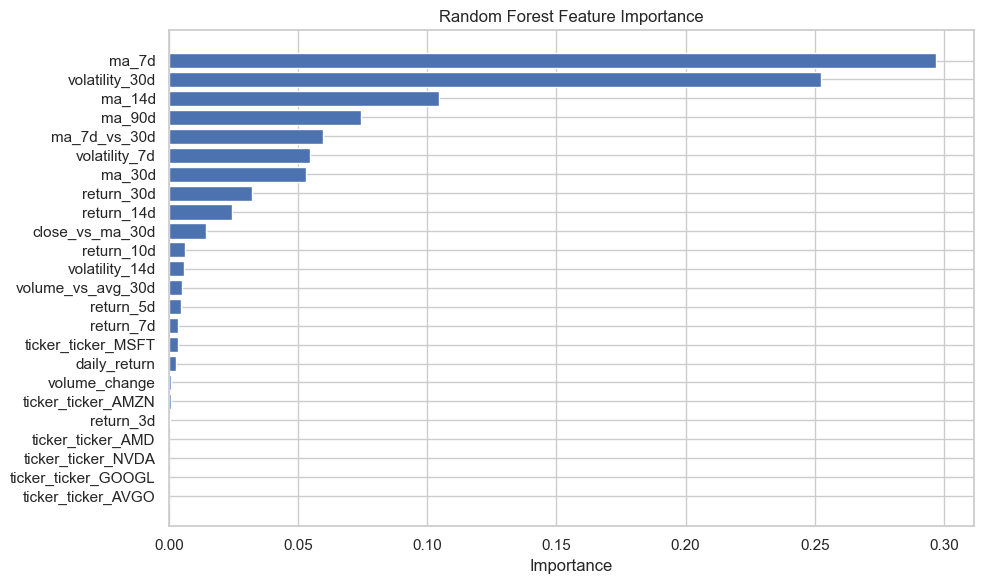

,feature,importance
7,ma_7d,0.296734
15,volatility_30d,0.252176
8,ma_14d,0.104558
10,ma_90d,0.074531
11,ma_7d_vs_30d,0.059706
13,volatility_7d,0.054642
9,ma_30d,0.053049
6,return_30d,0.032153
5,return_14d,0.024464
12,close_vs_ma_30d,0.014359


In [28]:
selected_estimator = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.replace("numeric__", "").replace("ticker__", "ticker_") for name in feature_names]

if hasattr(selected_estimator, "feature_importances_"):
    importance_values = selected_estimator.feature_importances_
    importance_label = "importance"
elif hasattr(selected_estimator, "coef_"):
    importance_values = abs(selected_estimator.coef_[0])
    importance_label = "absolute_coefficient"
else:
    importance_values = np.zeros(len(feature_names))
    importance_label = "importance"

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    importance_label: importance_values
}).sort_values(importance_label, ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["feature"], feature_importance_df[importance_label])
plt.title(f"{best_result['model']} Feature Importance")
plt.xlabel(importance_label.replace("_", " ").title())
plt.tight_layout()
plt.savefig("outputs/charts/model_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance_df.to_csv("outputs/model_results/model_feature_importance.csv", index=False)
feature_importance_df.sort_values(importance_label, ascending=False)


## 12. Current Prediction Rows

After choosing the best model setup, this section applies it to the newest rows where the future result is not known yet. These are prediction rows only, not training rows.

The prediction is whether the stock is likely to have a meaningful upward move over the selected number of trading days, not the exact future price.


In [29]:
latest_df = pd.read_csv("data/processed/latest_prediction_rows.csv")
latest_df["date"] = pd.to_datetime(latest_df["date"])
latest_features = latest_df.dropna(subset=best_feature_columns).copy()

latest_predictions = predict_with_threshold(best_model, latest_features[best_feature_columns], best_threshold)
latest_output_columns = ["date", "ticker", "close", "avg_sentiment_score", "article_count"]
latest_output = latest_features[latest_output_columns].copy()
latest_output["prediction_window_days"] = best_window
latest_output["predicted_up"] = latest_predictions
latest_output["target_cutoff_used"] = best_result["target_cutoff"]

if hasattr(best_model, "predict_proba"):
    latest_output["prediction_probability_up"] = best_model.predict_proba(latest_features[best_feature_columns])[:, 1]

latest_output = latest_output.sort_values("prediction_probability_up", ascending=False)
latest_output.to_csv("outputs/model_results/latest_direction_predictions.csv", index=False)
latest_output


,date,ticker,close,avg_sentiment_score,article_count,prediction_window_days,predicted_up,target_cutoff_used,prediction_probability_up
1,2026-05-27,AMZN,271.850006,0.433087,1,7,1,0.005,0.514232
4,2026-05-27,MSFT,412.670013,0.173975,47,7,1,0.005,0.509996
0,2026-05-27,AMD,495.540009,0.193455,31,7,1,0.005,0.440795
3,2026-05-27,GOOGL,388.829987,0.161826,27,7,0,0.005,0.429883
2,2026-05-27,AVGO,421.859985,0.190800,20,7,0,0.005,0.419649
5,2026-05-27,NVDA,212.600006,0.223289,50,7,0,0.005,0.412952
